# Color Image Processing

---
Point and line detection techniques are implemented to identify fundamental structural features within images as a preliminary step in segmentation. Edge detection methods are then applied to extract object boundaries and intensity discontinuities using gradient-based approaches. Region growing is performed to segment images based on pixel similarity and connectivity criteria, followed by region splitting and merging techniques to refine segmentation through hierarchical partitioning. Finally, various thresholding methods are implemented to separate foreground and background regions based on intensity distributions, providing a comprehensive exploration of classical image segmentation strategies.
---


### **1. Point and Line Detection in Image Segmentation**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


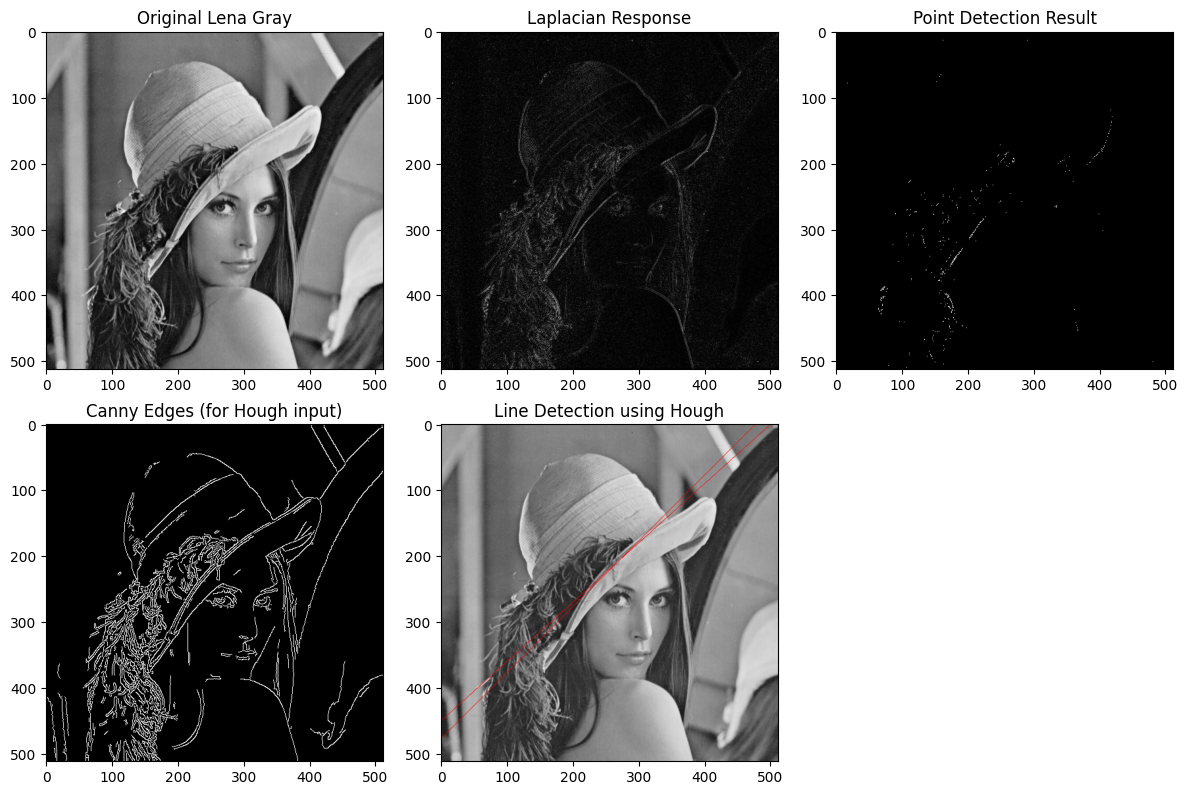

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Read Lena grayscale image
img = cv2.imread(r"/content/drive/MyDrive/CVIPDB/LAB_7/lena_gray.png", cv2.IMREAD_GRAYSCALE)

# --- (A) Point Detection using Laplacian ---
lap = cv2.Laplacian(img, cv2.CV_64F)
lap_abs = np.absolute(lap)
lap_norm = np.uint8(255 * lap_abs / np.max(lap_abs))

# Threshold to highlight strong point-like responses
_, point_detected = cv2.threshold(lap_norm, 120, 255, cv2.THRESH_BINARY)

# --- (B) Line Detection using Hough Transform ---
edges = cv2.Canny(img, 100, 200)
lines = cv2.HoughLines(edges, 1, np.pi/180, 150)

# Create RGB copy to draw lines
img_lines = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a*rho, b*rho
        x1, y1 = int(x0 + 1000*(-b)), int(y0 + 1000*(a))
        x2, y2 = int(x0 - 1000*(-b)), int(y0 - 1000*(a))
        cv2.line(img_lines, (x1, y1), (x2, y2), (0,0,255), 1)

# --- Display results ---
plt.figure(figsize=(12,8))
plt.subplot(231); plt.imshow(img, cmap='gray'); plt.title('Original Lena Gray')
plt.subplot(232); plt.imshow(lap_norm, cmap='gray'); plt.title('Laplacian Response')
plt.subplot(233); plt.imshow(point_detected, cmap='gray'); plt.title('Point Detection Result')
plt.subplot(234); plt.imshow(edges, cmap='gray'); plt.title('Canny Edges (for Hough input)')
plt.subplot(235); plt.imshow(img_lines[...,::-1]); plt.title('Line Detection using Hough')
plt.tight_layout()
plt.show()


**Obserrvation**

* Point Detection (Laplacian):

  * Highlights isolated high-intensity variations (corners, spots).

  * Sensitive to noise, so pre-filtering (Gaussian blur) may improve results.

  * Works well for fine texture or dot features.

* Line Detection (Hough Transform):

  * Detects straight lines by mapping edge pixels into parameter space (ρ, θ).

  * Robust to small gaps in edges and noise.

  * Red lines overlaid indicate detected linear features (borders, edges of face/hat in Lena).

* Comparison:

  * Laplacian is local (based on small neighborhood intensity changes).

  * Hough Transform is global (votes for extended straight structures).

  * Together they provide complementary segmentation cues: points mark local details, lines mark shape boundaries.

### **2. Edge Detection in Image Segmentation**

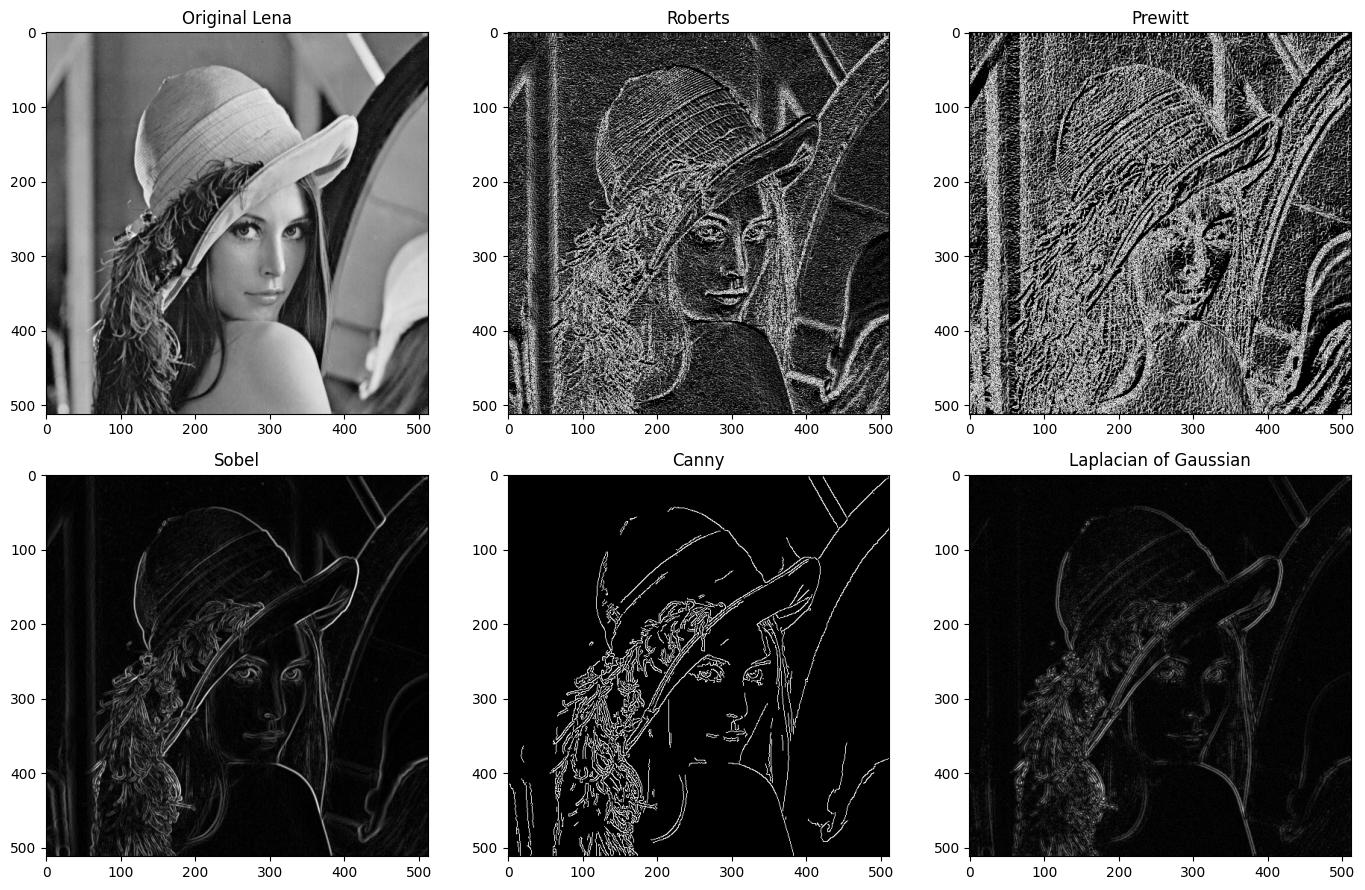

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img_path = "/content/drive/MyDrive/CVIPDB/LAB_7/lena_gray.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Roberts Filter
roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
edge_roberts = np.sqrt(
    cv2.filter2D(img, -1, roberts_x)**2 + cv2.filter2D(img, -1, roberts_y)**2
)
edge_roberts = np.uint8(255 * edge_roberts / np.max(edge_roberts))

# Prewitt Filter
prewitt_x = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
prewitt_y = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32)
edge_prewitt = np.sqrt(
    cv2.filter2D(img, -1, prewitt_x)**2 + cv2.filter2D(img, -1, prewitt_y)**2
)
edge_prewitt = np.uint8(255 * edge_prewitt / np.max(edge_prewitt))

# Sobel Filter
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
edge_sobel = np.sqrt(sobel_x**2 + sobel_y**2)
edge_sobel = np.uint8(255 * edge_sobel / np.max(edge_sobel))

# Canny Edge Detector
edge_canny = cv2.Canny(img, 100, 200)

# Laplacian of Gaussian (LoG)
img_blur = cv2.GaussianBlur(img, (5,5), 1)
edge_log = cv2.Laplacian(img_blur, cv2.CV_64F)
edge_log = np.uint8(255 * np.absolute(edge_log) / np.max(np.absolute(edge_log)))

# Display Results
plt.figure(figsize=(14,9))
plt.subplot(231); plt.imshow(img, cmap='gray'); plt.title('Original Lena')
plt.subplot(232); plt.imshow(edge_roberts, cmap='gray'); plt.title('Roberts')
plt.subplot(233); plt.imshow(edge_prewitt, cmap='gray'); plt.title('Prewitt')
plt.subplot(234); plt.imshow(edge_sobel, cmap='gray'); plt.title('Sobel')
plt.subplot(235); plt.imshow(edge_canny, cmap='gray'); plt.title('Canny')
plt.subplot(236); plt.imshow(edge_log, cmap='gray'); plt.title('Laplacian of Gaussian')
plt.tight_layout()
plt.show()


**Observations**

* Roberts: Detects fine edges but highly noise-sensitive.

* Prewitt: Produces thicker edges; moderate noise resistance.

* Sobel: Strong and smooth edges; widely used for general cases.

* Canny: Sharp, clean, and continuous edges; best overall.

* LoG: Highlights strong transitions but can create double edges.

### **3. Region growing**

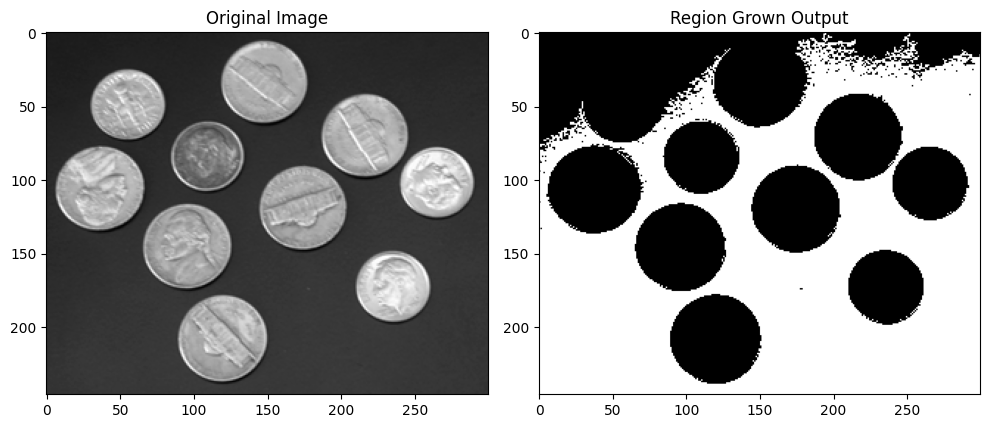

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# Read
img_path = "/content/drive/MyDrive/CVIPDB/LAB_7/coins.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


# Region Growing Function
def region_grow(img, seed, thresh=10):
    h, w = img.shape
    visited = np.zeros_like(img, dtype=bool)
    region = np.zeros_like(img, dtype=np.uint8)
    q = deque([seed])
    seed_val = img[seed]

    while q:
        x, y = q.popleft()
        if visited[x, y]:
            continue
        visited[x, y] = True
        region[x, y] = 255

        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                    if abs(int(img[nx, ny]) - int(seed_val)) < thresh:
                        q.append((nx, ny))
    return region

# Select a seed point
seed_point = (150, 150)
region_mask = region_grow(img, seed_point, thresh=12)

# Display
plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(img, cmap='gray'); plt.title('Original Image')
plt.subplot(122); plt.imshow(region_mask, cmap='gray'); plt.title('Region Grown Output')
plt.tight_layout()
plt.show()


**Observations**

* Region expands from a chosen seed based on pixel intensity similarity.

* Proper threshold selection is crucial — too low → under-segmentation; too high → leakage.

* Works well for uniform objects like coins or simple textures.

### **4. Region Splitting and Merging**

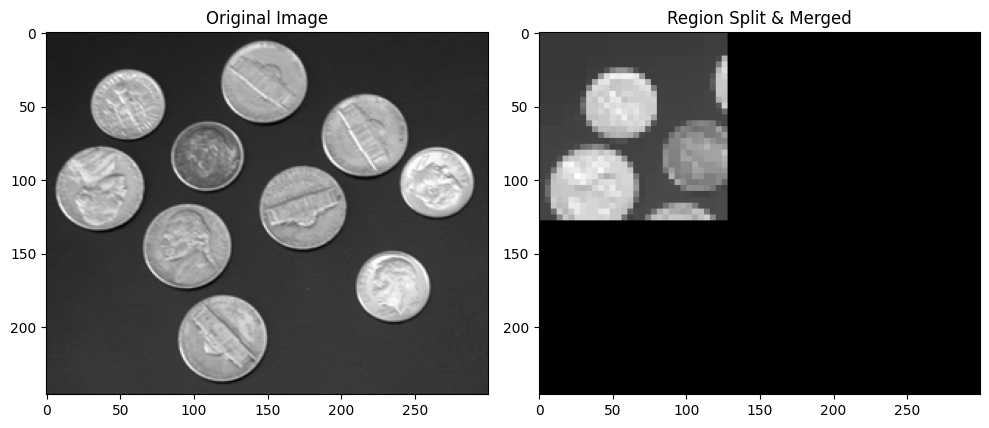

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read
img_path = "/content/drive/MyDrive/CVIPDB/LAB_7/coins.png"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Define homogeneity criterion
def is_homogeneous(region, threshold=15):
    return np.std(region) < threshold

# Recursive region splitting
def split_region(img, x, y, size, threshold):
    sub = img[x:x+size, y:y+size]
    if sub.size == 0:
        return []
    if is_homogeneous(sub, threshold) or size < 8:
        return [(x, y, size)]
    half = size // 2
    return (
        split_region(img, x, y, half, threshold) +
        split_region(img, x, y+half, half, threshold) +
        split_region(img, x+half, y, half, threshold) +
        split_region(img, x+half, y+half, half, threshold)
    )

# Merging step
def merge_regions(img, regions, threshold):
    merged = np.zeros_like(img)
    for (x, y, size) in regions:
        mean_val = np.mean(img[x:x+size, y:y+size])
        merged[x:x+size, y:y+size] = mean_val
    return np.uint8(merged)

# Apply region splitting and merging
h, w = img.shape
size = 2 ** int(np.floor(np.log2(min(h, w))))  # power of 2
regions = split_region(img, 0, 0, size, threshold=12)
merged_img = merge_regions(img, regions, threshold=12)

# Display results
plt.figure(figsize=(10,5))
plt.subplot(121); plt.imshow(img, cmap='gray'); plt.title("Original Image")
plt.subplot(122); plt.imshow(merged_img, cmap='gray'); plt.title("Region Split & Merged")
plt.tight_layout()
plt.show()


**Observations**

* Image recursively divides until each region becomes uniform in intensity.

* Merging smooths homogeneous areas and reduces noise.

* Produces piecewise uniform regions suitable for segmentation tasks.

### **5. Thresholding methods**

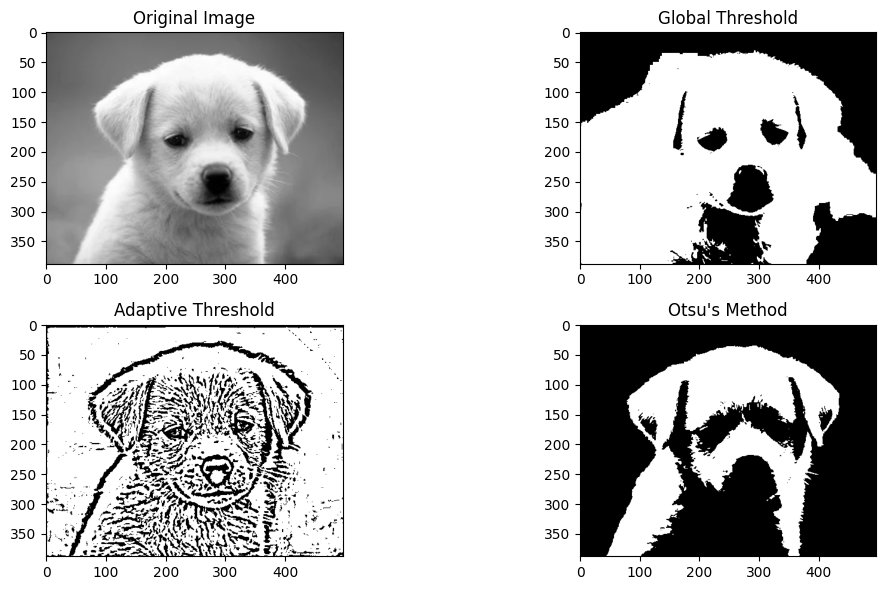

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read imag
img_path = "/content/drive/MyDrive/CVIPDB/LAB_7/dog.PNG"
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


# Global Thresholding
_, global_thresh = cv2.threshold(img, 120, 255, cv2.THRESH_BINARY)

# Adaptive Thresholding (Mean)
adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                      cv2.THRESH_BINARY, 11, 2)

# Otsu's Thresholding
_, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display results
plt.figure(figsize=(12,6))
plt.subplot(221); plt.imshow(img, cmap='gray'); plt.title("Original Image")
plt.subplot(222); plt.imshow(global_thresh, cmap='gray'); plt.title("Global Threshold")
plt.subplot(223); plt.imshow(adaptive_mean, cmap='gray'); plt.title("Adaptive Threshold")
plt.subplot(224); plt.imshow(otsu_thresh, cmap='gray'); plt.title("Otsu's Method")
plt.tight_layout()
plt.show()


**Observations**

* Global: Works only if lighting is uniform.

* Adaptive: Handles uneven illumination well by using local neighborhood stats.

* Otsu: Automatically finds the best threshold; ideal for bimodal histograms.